# 11 - HURDLE benchmark products

This notebook reuses the existing project `HurdleModel` and the existing project feature engineering logic, adapted to the official three-product M5 benchmark.

Benchmark products:
- `FOODS_3_228_CA_1_validation` (`high_demand_stable`)
- `FOODS_2_044_CA_3_validation` (`intermittent`)
- `HOBBIES_1_133_CA_4_validation` (`low_volume`)

Official protocol:
- `MAX_DAYS = 365`
- `CONTEXT_LENGTH = 28`
- `VAL_DAYS = 28`
- `TEST_DAYS = 28`
- train = `309`, validation = `28`, fit = `337`, test = final `28`

Note: HURDLE does not use context windows the same way as neural models. For fairness, we keep the exact same final horizon and chronological split.

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'gnn_model_comparison':
    ROOT = ROOT.parents[1]
elif ROOT.name == 'notebooks':
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = ROOT / 'reports' / 'gnn_benchmarks' / 'hurdle_benchmark_products'
OUT_DIR


WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/hurdle_benchmark_products')

## Existing project code reused

- `src/models/hurdle_model.py`
- feature engineering adapted from `src/experiments/run_hurdle_benchmark.py`
- benchmark evaluation style aligned with the newer benchmark notebooks

Adaptation note:
- rolling features were kept conceptually the same, but shifted to avoid same-day target leakage


In [3]:
from src.experiments.run_hurdle_benchmark_products import main

main()


[RUN] FOODS_3_228_CA_1_validation | occurrence=logistic_regression | quantity=ridge_log_size | mae=3.239571 | vr=0.894939 | flat=non-flat
[RUN] FOODS_2_044_CA_3_validation | occurrence=logistic_regression | quantity=ridge_log_size | mae=1.129554 | vr=0.137035 | flat=non-flat
[RUN] HOBBIES_1_133_CA_4_validation | occurrence=logistic_regression | quantity=ridge_log_size | mae=0.004546 | vr=0.000000 | flat=flat
[OK] Saved metrics -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\hurdle_benchmark_products\metrics.csv
[OK] Saved training summary -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\hurdle_benchmark_products\training_summary.csv
[OK] Saved summary -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\hurdle_benchmark_products\summary.csv
[OK] Saved predictions -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\hurdle_benchmark

In [4]:
import pandas as pd

training_summary_df = pd.read_csv(OUT_DIR / 'training_summary.csv')
metrics_df = pd.read_csv(OUT_DIR / 'metrics.csv')
summary_df = pd.read_csv(OUT_DIR / 'summary.csv')

training_summary_df


,series_id,benchmark_label,model,occurrence_mode,quantity_mode,final_loss,context_length,train_days,fit_days
0,FOODS_3_228_CA_1_validation,high_demand_stable,HURDLE,logistic_regression,ridge_log_size,NaN,28,309,337
1,FOODS_2_044_CA_3_validation,intermittent,HURDLE,logistic_regression,ridge_log_size,NaN,28,309,337
2,HOBBIES_1_133_CA_4_validation,low_volume,HURDLE,logistic_regression,ridge_log_size,NaN,28,309,337


In [5]:
summary_df


,series_id,benchmark_label,final_loss,mae,rmse,pred_std,real_std,variance_ratio,trend_correlation,direction_accuracy,shape_similarity,peak_detection_rate,flat_nonflat
0,FOODS_3_228_CA_1_validation,high_demand_stable,NaN,3.239571,4.047823,2.489558,2.781820,0.894939,0.374567,0.296296,0.659871,0.875,non-flat
1,FOODS_2_044_CA_3_validation,intermittent,NaN,1.129554,1.449480,0.199641,1.456863,0.137035,0.230195,0.407407,0.685530,0.000,non-flat
2,HOBBIES_1_133_CA_4_validation,low_volume,NaN,0.004546,0.005136,0.002390,0.000000,0.000000,NaN,0.000000,0.688347,1.000,flat


WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/hurdle_benchmark_products/figures/high_demand_stable_FOODS_3_228_CA_1_validation_real_vs_predicted.png')

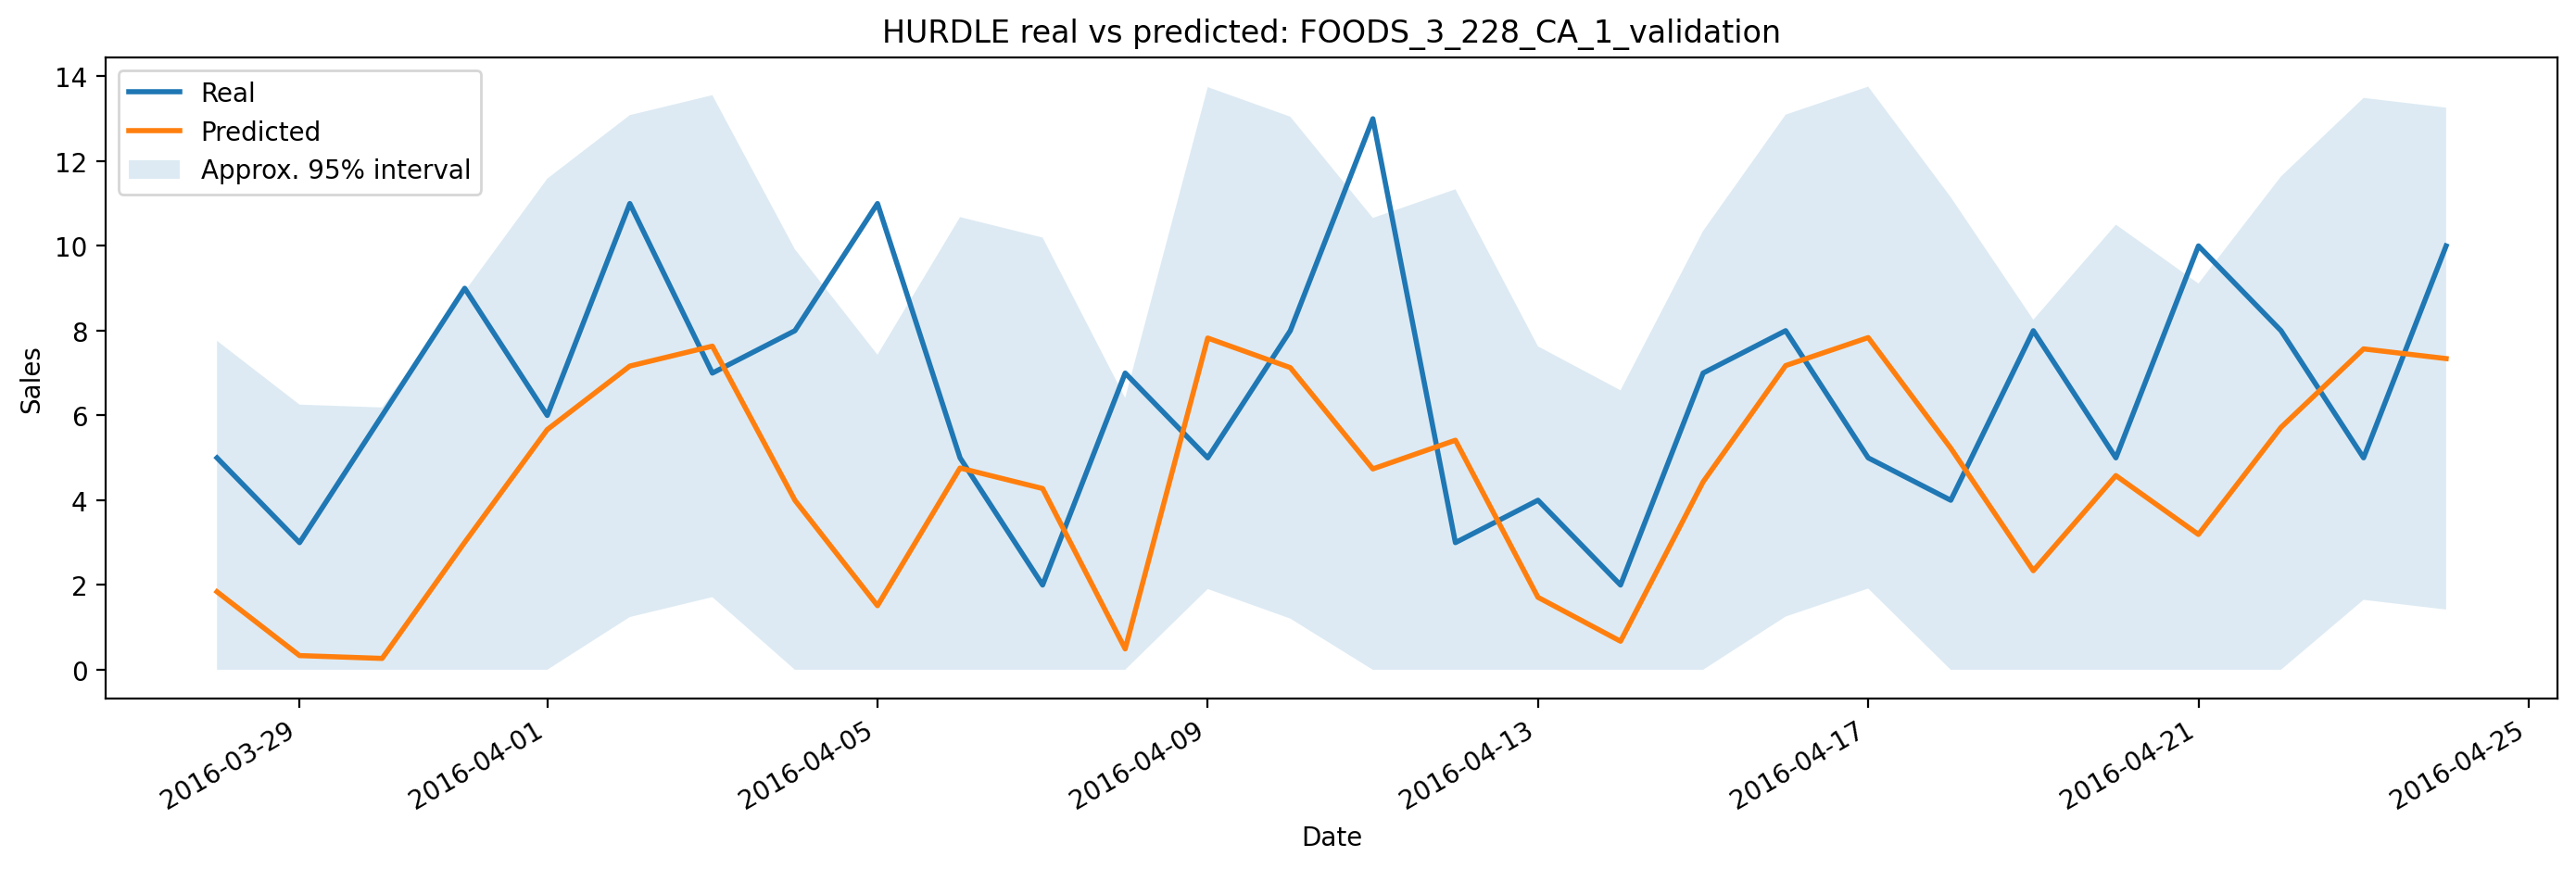

WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/hurdle_benchmark_products/figures/intermittent_FOODS_2_044_CA_3_validation_real_vs_predicted.png')

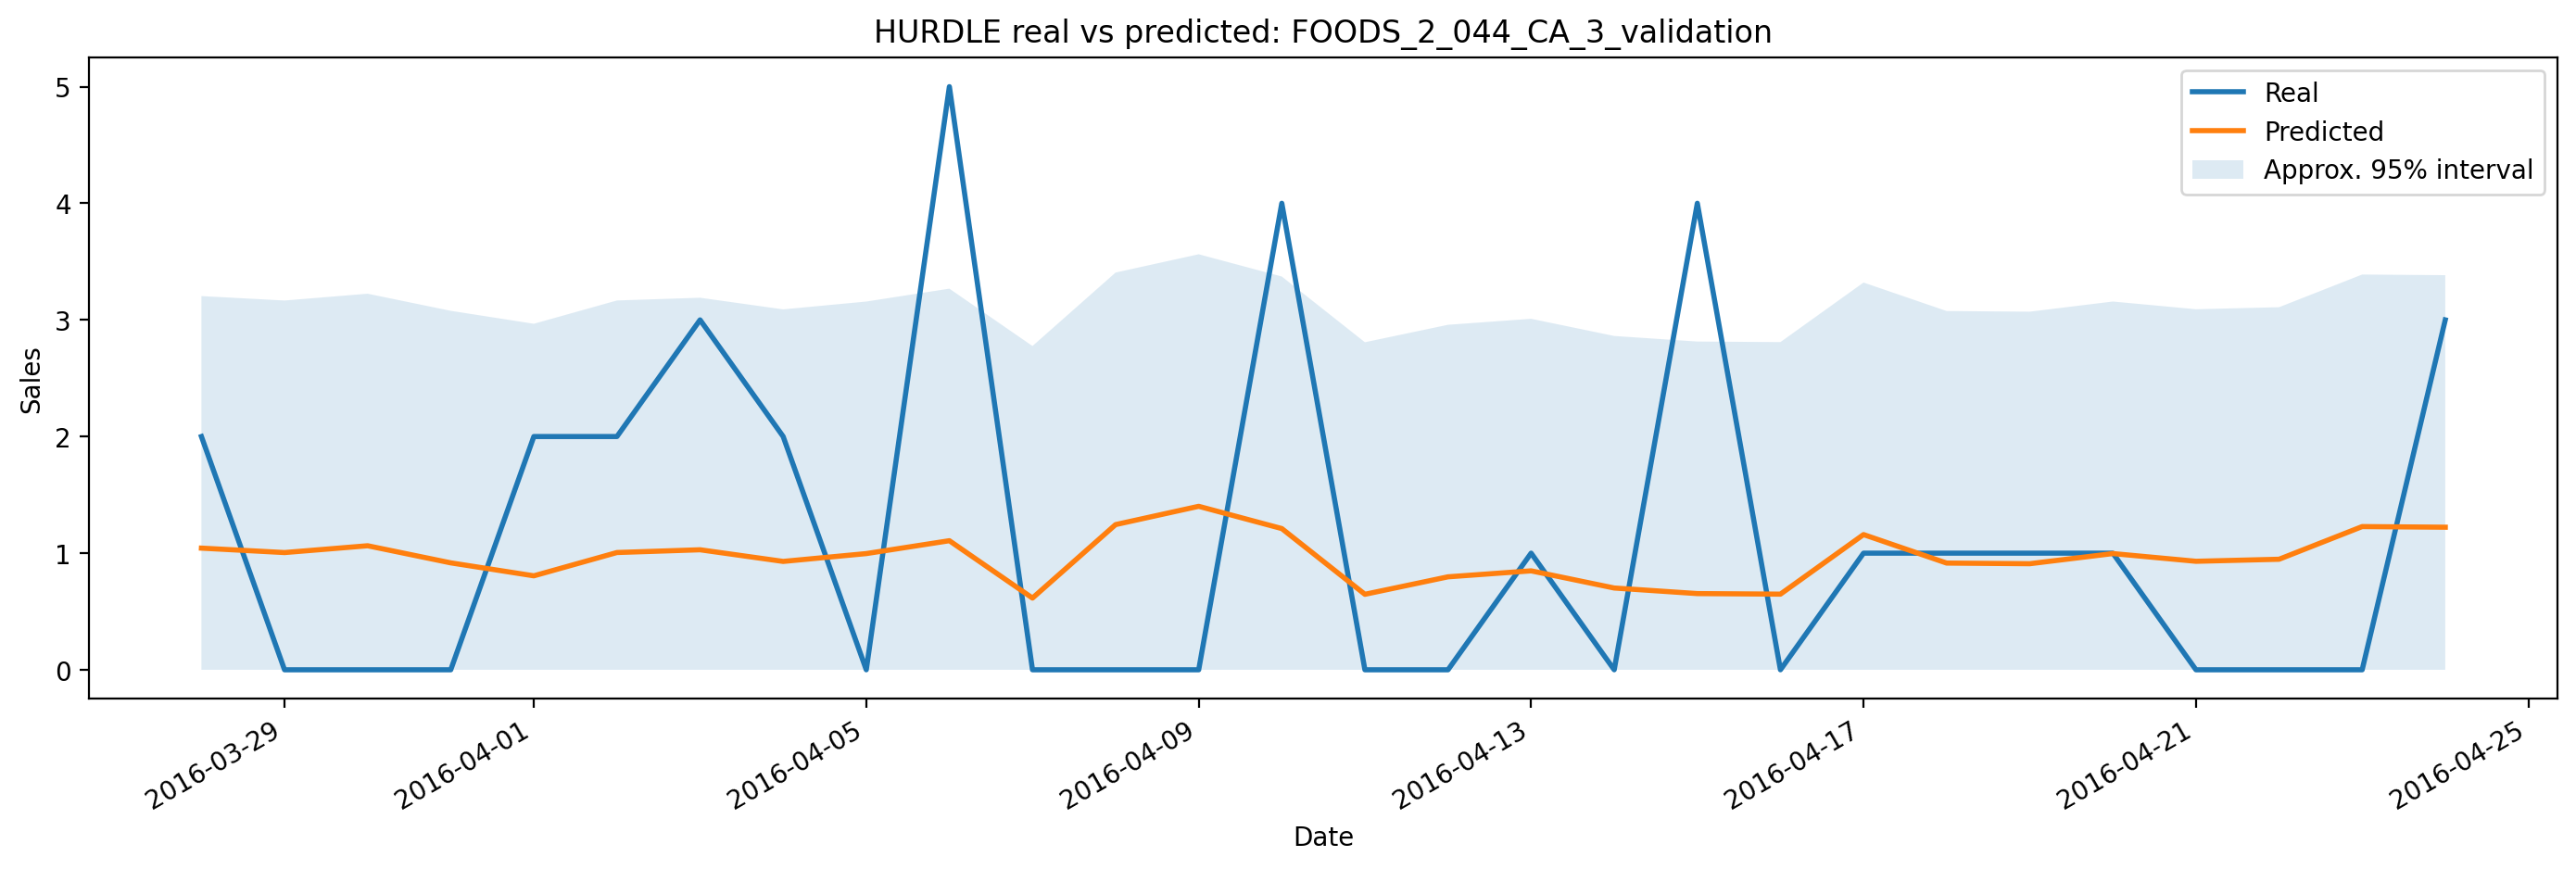

WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/hurdle_benchmark_products/figures/low_volume_HOBBIES_1_133_CA_4_validation_real_vs_predicted.png')

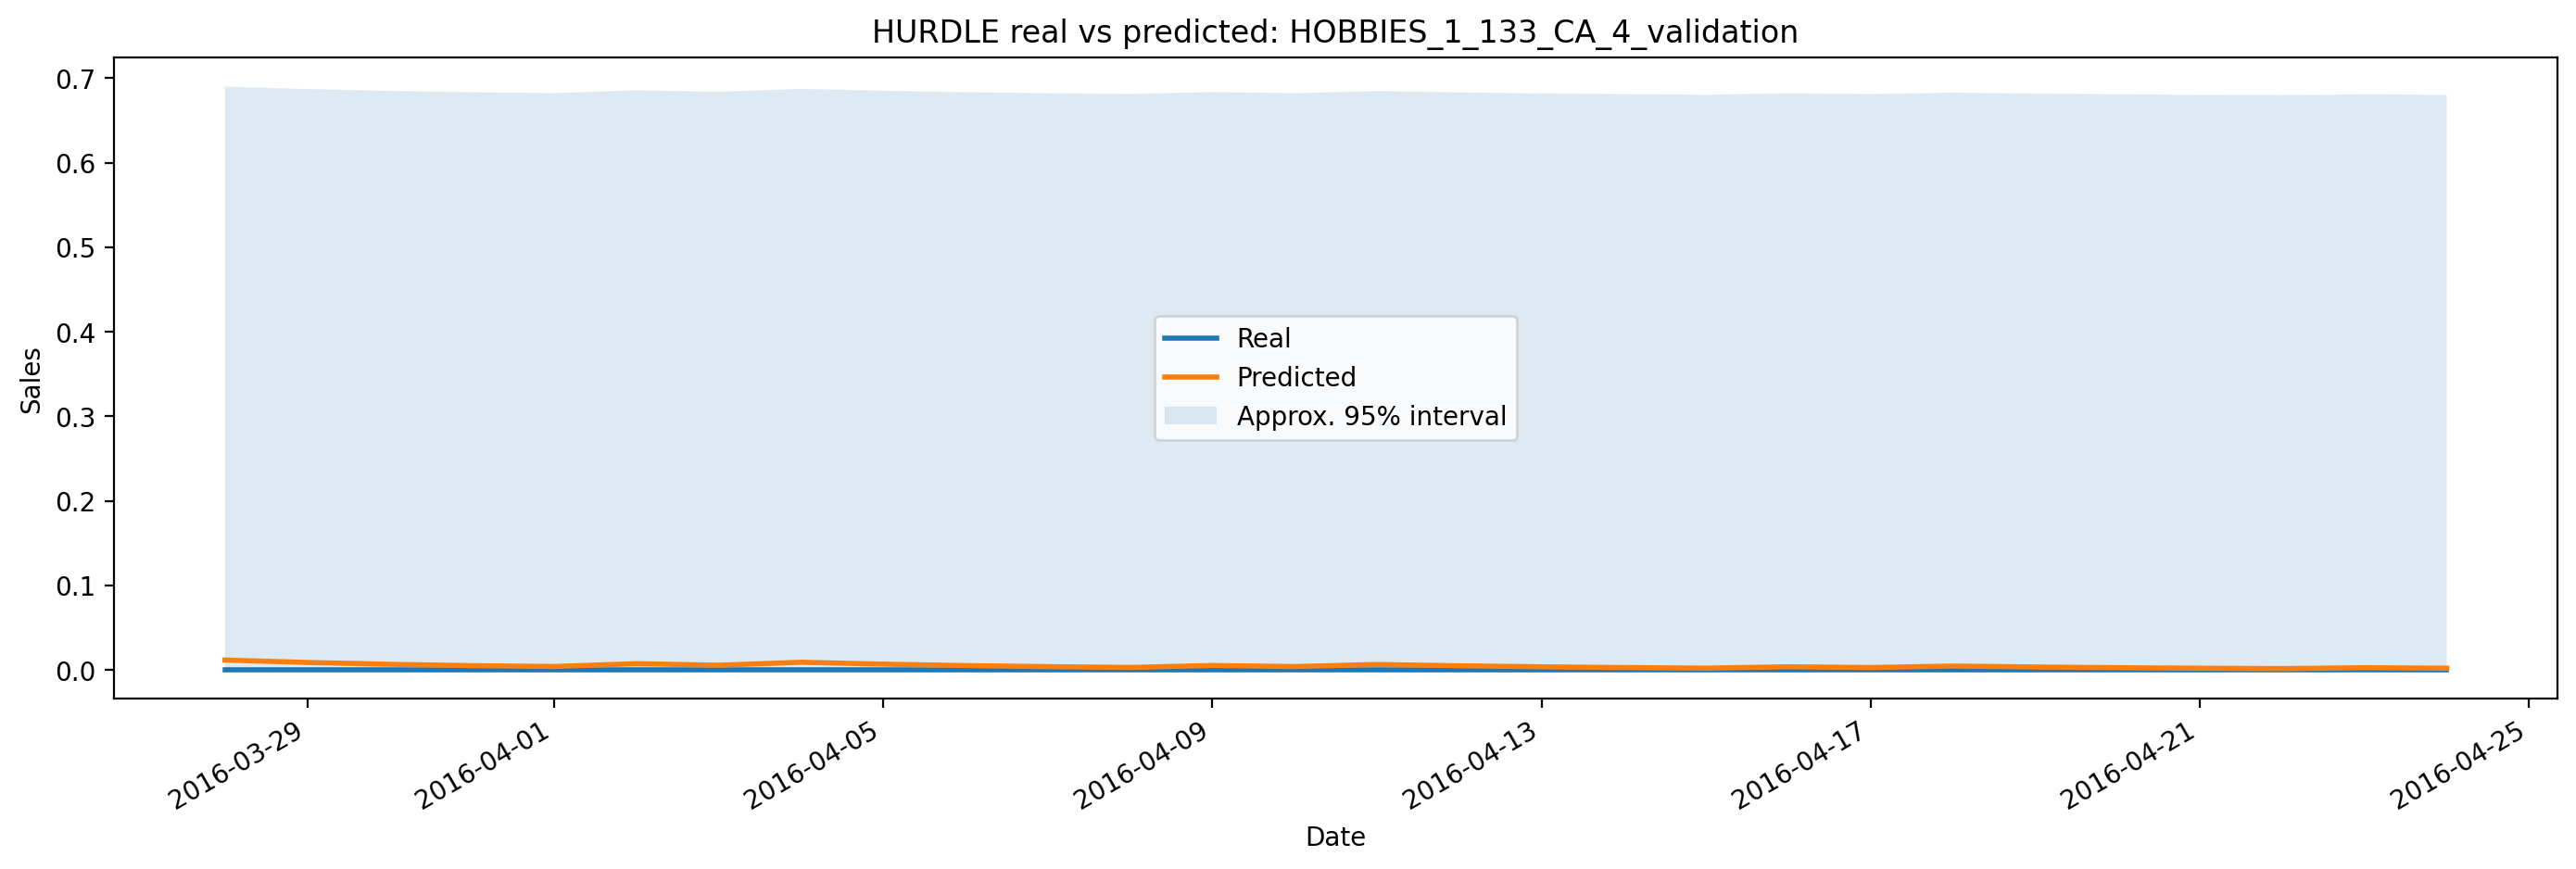

In [6]:
from IPython.display import Image, display

for label, series_id in [
    ('high_demand_stable', 'FOODS_3_228_CA_1_validation'),
    ('intermittent', 'FOODS_2_044_CA_3_validation'),
    ('low_volume', 'HOBBIES_1_133_CA_4_validation'),
]:
    path = OUT_DIR / 'figures' / f'{label}_{series_id}_real_vs_predicted.png'
    display(path)
    display(Image(filename=str(path)))
